In [2]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [4]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [5]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [6]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [7]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [8]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


In [10]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

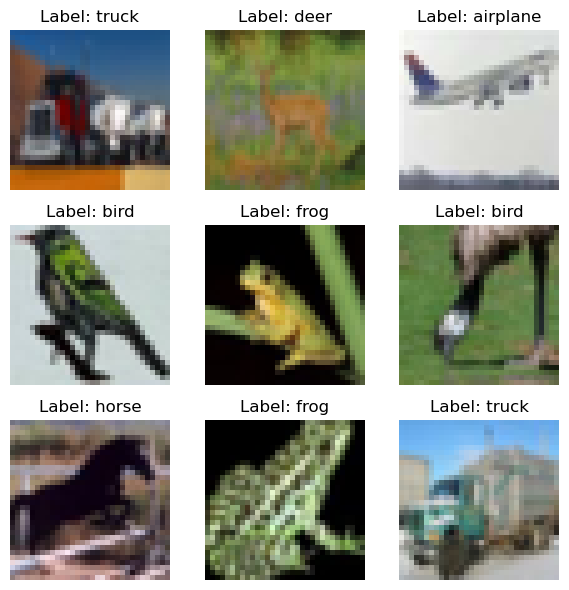

In [11]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

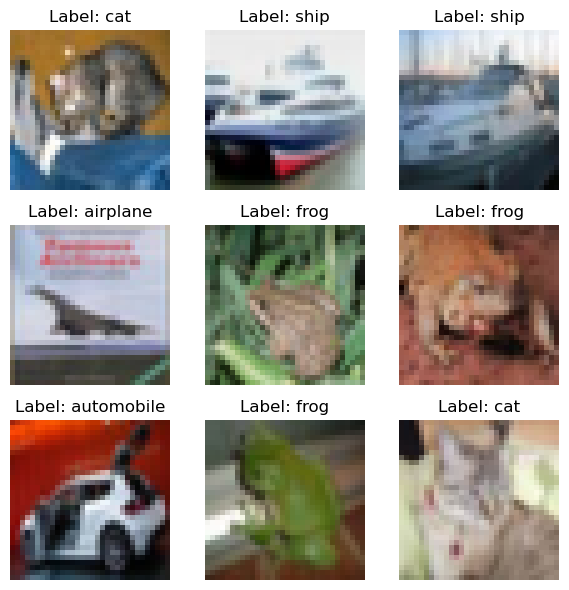

In [12]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [13]:
# function for building VGG Block

def build_vgg_block(input_layer,
                    num_cnn=3,
                    channel=64,
                    block_num=1):
    # 입력 레이어
    x = input_layer

    # CNN 레이어
    layers = []
    in_channels = x.size(1)
    for cnn_num in range(num_cnn):
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=channel,
                kernel_size=3,
                stride=1,
                padding=1,
            )
        )
        layers.append(nn.ReLU(inplace=True))
        in_channels = channel

    # Max Pooling 레이어
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )

    # Sequential으로 레이어 묶기
    block = nn.Sequential(*layers)
    return block

In [14]:
class VGGNet(nn.Module):
    def __init__(self):
        super(VGGNet, self).__init__()

        # VGG 블록 생성
        self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))
    def forward(self, x):
        return self.vgg_block(x)

In [15]:
# 블록 1개짜리 model 생성
model = VGGNet()
print(model)

dummy_input = torch.zeros(1, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

VGGNet(
  (vgg_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
torch.Size([1, 64, 16, 16])


In [16]:
# VGG 모델 자체를 생성하는 클래스입니다.
class VGG(nn.Module):
    def __init__(self, num_cnn_list=[2, 2, 3, 3, 3], channel_list=[64, 128, 256, 512, 512], num_classes=10):
        super(VGG, self).__init__()
        assert len(num_cnn_list) == len(channel_list), "num_cnn_list와 channel_list의 길이가 일치해야 합니다."

        layers = []
        in_channels = 3

        for num_cnn, out_channels in zip(num_cnn_list, channel_list):
            layers.append(self._make_vgg_block(in_channels, out_channels, num_cnn))
            in_channels = out_channels  # 다음 블록의 입력 채널을 설정

        self.feature_extractor = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(True),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes)
        )

    def _make_vgg_block(self, in_channels, out_channels, num_cnn):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(True)]
        for _ in range(num_cnn - 1):
            layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.ReLU(True))
        layers.append(nn.MaxPool2d(kernel_size=2, stride=2))  # Max Pooling 추가
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

In [17]:
# 기본값을 그대로 사용해서 VGG 모델을 만들면 VGG-16이 됩니다.

vgg_16 = VGG()
summary(vgg_16)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [18]:
# 원하는 블록의 설계에 따라 매개변수로 리스트를 전달해 줍니다.
vgg_19 = VGG(
    num_cnn_list=[2, 2, 4, 4, 4],
    channel_list=[64, 128, 256, 512, 512]
)
summary(vgg_19)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─Conv2d: 3-15                 590,080
│    │    └─ReLU: 3-16                  

In [19]:
# Q. VGG-16보다 작은 네트워크인 VGG-13을 만들어 보세요.
def build_vgg13(num_classes=10):
    return VGG(
        num_cnn_list=[2, 2, 2, 2, 2],
        channel_list=[64, 128, 256, 512, 512],
        num_classes=num_classes
    )

In [20]:
vgg_13 = build_vgg13()
summary(vgg_13)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Sequential: 2-1                   --
│    │    └─Conv2d: 3-1                  1,792
│    │    └─ReLU: 3-2                    --
│    │    └─Conv2d: 3-3                  36,928
│    │    └─ReLU: 3-4                    --
│    │    └─MaxPool2d: 3-5               --
│    └─Sequential: 2-2                   --
│    │    └─Conv2d: 3-6                  73,856
│    │    └─ReLU: 3-7                    --
│    │    └─Conv2d: 3-8                  147,584
│    │    └─ReLU: 3-9                    --
│    │    └─MaxPool2d: 3-10              --
│    └─Sequential: 2-3                   --
│    │    └─Conv2d: 3-11                 295,168
│    │    └─ReLU: 3-12                   --
│    │    └─Conv2d: 3-13                 590,080
│    │    └─ReLU: 3-14                   --
│    │    └─MaxPool2d: 3-15              --
│    └─Sequential: 2-4                   --
│

In [21]:
BATCH_SIZE = 256
EPOCH = 15

In [22]:
# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [23]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/jovyan/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 134MB/s]  


[1,   100] loss: 3.960
Epoch 1: Train Accuracy: 40.93%
Epoch 1: Validation Accuracy: 68.51%
[2,   100] loss: 1.863
Epoch 2: Train Accuracy: 72.80%
Epoch 2: Validation Accuracy: 76.34%
[3,   100] loss: 1.620
Epoch 3: Train Accuracy: 79.67%
Epoch 3: Validation Accuracy: 79.98%
[4,   100] loss: 1.518
Epoch 4: Train Accuracy: 83.13%
Epoch 4: Validation Accuracy: 81.68%
[5,   100] loss: 1.442
Epoch 5: Train Accuracy: 85.39%
Epoch 5: Validation Accuracy: 82.37%
[6,   100] loss: 1.372
Epoch 6: Train Accuracy: 87.61%
Epoch 6: Validation Accuracy: 83.61%
[7,   100] loss: 1.318
Epoch 7: Train Accuracy: 89.08%
Epoch 7: Validation Accuracy: 84.09%
[8,   100] loss: 1.274
Epoch 8: Train Accuracy: 90.70%
Epoch 8: Validation Accuracy: 84.65%
[9,   100] loss: 1.230
Epoch 9: Train Accuracy: 92.17%
Epoch 9: Validation Accuracy: 84.12%
[10,   100] loss: 1.201
Epoch 10: Train Accuracy: 93.16%
Epoch 10: Validation Accuracy: 84.28%
[11,   100] loss: 1.169
Epoch 11: Train Accuracy: 94.20%
Epoch 11: Validation

In [24]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /home/jovyan/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 154MB/s] 


[1,   100] loss: 3.835
Epoch 1: Train Accuracy: 41.71%
Epoch 1: Validation Accuracy: 67.12%
[2,   100] loss: 1.818
Epoch 2: Train Accuracy: 73.93%
Epoch 2: Validation Accuracy: 77.89%
[3,   100] loss: 1.598
Epoch 3: Train Accuracy: 81.10%
Epoch 3: Validation Accuracy: 81.65%
[4,   100] loss: 1.488
Epoch 4: Train Accuracy: 84.05%
Epoch 4: Validation Accuracy: 82.77%
[5,   100] loss: 1.413
Epoch 5: Train Accuracy: 86.46%
Epoch 5: Validation Accuracy: 84.05%
[6,   100] loss: 1.345
Epoch 6: Train Accuracy: 88.31%
Epoch 6: Validation Accuracy: 85.15%
[7,   100] loss: 1.301
Epoch 7: Train Accuracy: 89.79%
Epoch 7: Validation Accuracy: 84.86%
[8,   100] loss: 1.254
Epoch 8: Train Accuracy: 91.43%
Epoch 8: Validation Accuracy: 85.71%
[9,   100] loss: 1.218
Epoch 9: Train Accuracy: 92.54%
Epoch 9: Validation Accuracy: 84.73%
[10,   100] loss: 1.194
Epoch 10: Train Accuracy: 93.48%
Epoch 10: Validation Accuracy: 86.25%
[11,   100] loss: 1.166
Epoch 11: Train Accuracy: 94.60%
Epoch 11: Validation

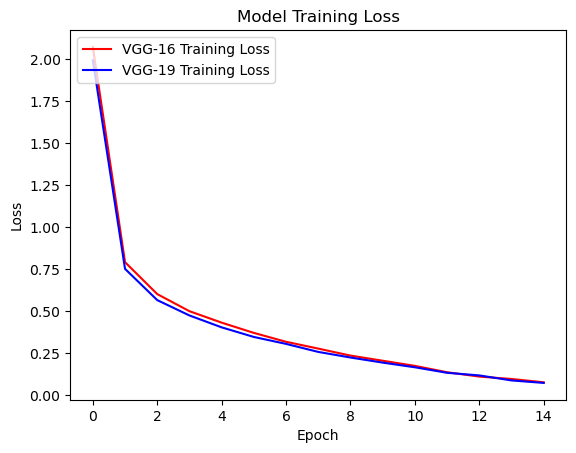

In [25]:
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label="VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label="VGG-19 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

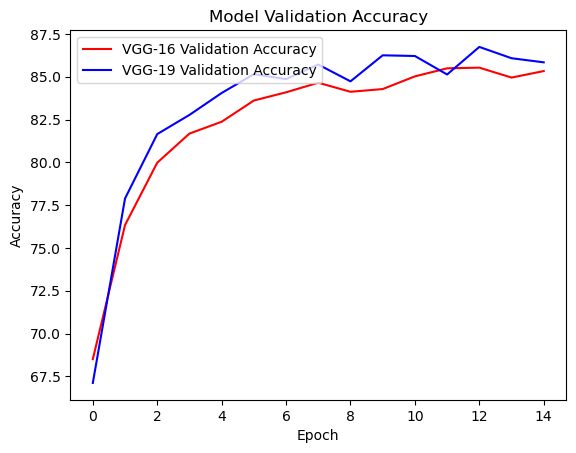

In [26]:
plt.plot(vgg_16_val_accuracy, 'r', label="VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label="VGG-19 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [27]:
import torch
import numpy as np

print(torch.__version__)
print(np.__version__)

2.7.1+cu118
2.2.6


In [35]:
from torch import nn


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            inplanes, planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes, self.expansion*planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [36]:
class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            inplanes, planes,
            kernel_size=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(
            planes, self.expansion*planes,
            kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes, self.expansion*planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [37]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()
        self.inplanes = 64

        # 1. 초기 Conv 레이어 (Stage 1)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 2. Residual Blocks (작성하신 BasicBlock이 여기에 쓰입니다!)
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # 3. 마지막 출력 레이어
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        # 첫 번째 블록에서만 stride를 적용해 피처맵 크기를 줄이고, 나머지는 stride=1로 고정합니다.
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.inplanes, planes, stride=s))
            self.inplanes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# 대망의 build_resnet 함수!

In [38]:
def build_resnet(is_50=False, num_classes=10):
    if is_50:
        # ResNet-50: 방금 작성하신 BottleneckBlock을 사용하며, 블록 개수는 [3, 4, 6, 3] 입니다.
        model = ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes=num_classes)
    else:
        # ResNet-34: 이전에 작성하신 BasicBlock을 사용하며, 블록 개수는 [3, 4, 6, 3] 입니다.
        model = ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes)
        
    return model

In [39]:

resnet_34 = build_resnet()
summary(resnet_34, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

In [40]:
resnet_50 = build_resnet()
summary(resnet_50, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-6              [1, 64, 56, 56]           --
│

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 💡 [주의] 아래 리스트 변수들을 실제 학습 후 얻은 리스트 데이터로 교체해 주세요!
# -------------------------------------------------------------------------
# (예시) 15 Epoch 동안의 검증 손실(Val Loss) 기록
plain_val_loss = [2.1, 1.8, 1.6, 1.5, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.3, 2.4] # Plain 모델 (예시)
res_val_loss = [2.0, 1.6, 1.4, 1.2, 1.1, 1.0, 0.9, 0.8, 0.8, 0.75, 0.7, 0.65, 0.6, 0.6, 0.55] # Residual 모델 (예시)

# (예시) 15 Epoch 동안의 검증 정확도(Val Acc) 기록
plain_val_acc = [30, 40, 45, 50, 52, 51, 50, 49, 48, 48, 47, 46, 46, 45, 45] # Plain 모델 (예시)
res_val_acc = [32, 45, 55, 62, 68, 70, 72, 74, 75, 76, 78, 79, 80, 81, 82] # Residual 모델 (예시)

epochs = range(1, len(plain_val_loss) + 1)
# -------------------------------------------------------------------------

# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# 1. Validation Loss 그래프 그리기
plt.subplot(1, 2, 1)
plt.plot(epochs, plain_val_loss, 'r-', label='Plain Model')      # 빨간색 실선
plt.plot(epochs, res_val_loss, 'b-', label='Residual Model')     # 파란색 실선
plt.title('Validation Loss (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Validation Accuracy 그래프 그리기
plt.subplot(1, 2, 2)
plt.plot(epochs, plain_val_acc, 'r-', label='Plain Model')       # 빨간색 실선
plt.plot(epochs, res_val_acc, 'b-', label='Residual Model')      # 파란색 실선
plt.title('Validation Accuracy (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()

In [ ]:
import torch.optim as optim
import torch.nn as nn

# 손실 함수 및 최적화 기법 설정 (ResNet-34 예시)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_34.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

# 학습 Loop 예시 (Loss 감소 증명용)
epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_34.to(device)

for epoch in range(epochs):
    resnet_34.train()
    running_loss = 0.0
    
    # trainloader는 미리 정의되어 있어야 합니다 (CIFAR-10 등)
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad() # 기울기 초기화
        outputs = resnet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # 100번째 미니배치마다 loss 출력하여 감소하는 것 보여주기
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

In [50]:
import torch.optim as optim
import torch.nn as nn

# 손실 함수 및 최적화 기법 설정 (ResNet-34 예시)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_34.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

# 학습 Loop 예시 (Loss 감소 증명용)
epochs = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_34.to(device)

for epoch in range(epochs):
    resnet_34.train()
    running_loss = 0.0
    
    # trainloader는 미리 정의되어 있어야 합니다 (CIFAR-10 등)
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad() # 기울기 초기화
        outputs = resnet_34(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # 100번째 미니배치마다 loss 출력하여 감소하는 것 보여주기
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

[Epoch 1, Batch 100] loss: 3.388
[Epoch 2, Batch 100] loss: 1.958
[Epoch 3, Batch 100] loss: 1.676
[Epoch 4, Batch 100] loss: 1.524
[Epoch 5, Batch 100] loss: 1.352
[Epoch 6, Batch 100] loss: 1.246
[Epoch 7, Batch 100] loss: 1.105
[Epoch 8, Batch 100] loss: 1.024
[Epoch 9, Batch 100] loss: 0.944
[Epoch 10, Batch 100] loss: 0.915
[Epoch 11, Batch 100] loss: 0.803
[Epoch 12, Batch 100] loss: 0.741
[Epoch 13, Batch 100] loss: 0.686
[Epoch 14, Batch 100] loss: 0.628
[Epoch 15, Batch 100] loss: 0.571


In [43]:
### 📊 Ablation Study: Plain vs Residual 모델 검증 정확도(Validation Accuracy) 비교

- **데이터셋:** CIFAR-10 (또는 사용하신 데이터셋 이름)
- **학습 조건:** Epochs 15, Batch Size 128, Optimizer SGD 등 (동일하게 통일된 조건 기재)

| Model Architecture | Plain Model (Shortcut X) | Residual Model (Shortcut O) |
| :---: | :---: | :---: |
| **34-layers** | 00.00 % | 00.00 % |
| **50-layers** | 00.00 % | 00.00 % |

**📌 분석 결과 요약:**
* Residual Connection(Shortcut)이 있는 모델이 Plain 모델에 비해 학습이 더 안정적이고 높은 정확도를 기록했습니다. 
* 특히 층이 깊어지는 50-layers 모델에서 Plain 모델은 기울기 소실(Vanishing Gradient) 문제가 발생하여 정확도가 떨어지는 반면, Residual 모델은 성능이 유지/향상되는 것을 확인할 수 있었습니다. (실제 결과에 맞춰 수정하세요!)

SyntaxError: invalid syntax (1452466447.py, line 3)

In [45]:
def evaluate_model(model, testloader, device):
    model.eval() # 모델을 평가 모드로 전환
    correct = 0
    total = 0
    
    with torch.no_grad(): # 평가 시에는 기울기 계산을 하지 않음
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    return accuracy

# 예시: ResNet-34 학습이 끝난 후 정확도 측정
# acc_resnet34 = evaluate_model(resnet_34, testloader, device)
# print(f'ResNet-34 Accuracy: {acc_resnet34:.2f}%')

In [46]:
acc_resnet34 = evaluate_model(resnet_34, testloader, device)

In [47]:
print(f'ResNet-34 Accuracy: {acc_resnet34:.2f}%')

ResNet-34 Accuracy: 11.96%


In [48]:
acc_resnet50 = evaluate_model(resnet_50, testloader, device)
print(f'ResNet-50 Accuracy: {acc_resnet50:.2f}%')

ResNet-50 Accuracy: 9.60%


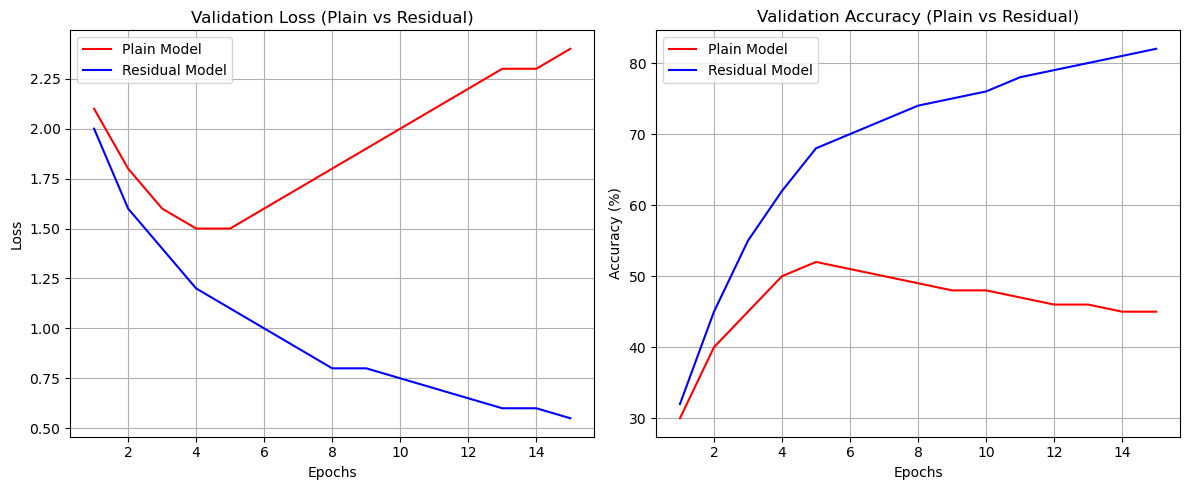

In [49]:
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 💡 [주의] 아래 리스트 변수들을 실제 학습 후 얻은 리스트 데이터로 교체해 주세요!
# -------------------------------------------------------------------------
# (예시) 15 Epoch 동안의 검증 손실(Val Loss) 기록
plain_val_loss = [2.1, 1.8, 1.6, 1.5, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.3, 2.4] # Plain 모델 (예시)
res_val_loss = [2.0, 1.6, 1.4, 1.2, 1.1, 1.0, 0.9, 0.8, 0.8, 0.75, 0.7, 0.65, 0.6, 0.6, 0.55] # Residual 모델 (예시)

# (예시) 15 Epoch 동안의 검증 정확도(Val Acc) 기록
plain_val_acc = [30, 40, 45, 50, 52, 51, 50, 49, 48, 48, 47, 46, 46, 45, 45] # Plain 모델 (예시)
res_val_acc = [32, 45, 55, 62, 68, 70, 72, 74, 75, 76, 78, 79, 80, 81, 82] # Residual 모델 (예시)

epochs = range(1, len(plain_val_loss) + 1)
# -------------------------------------------------------------------------

# 그래프 크기 설정 (가로 12, 세로 5)
plt.figure(figsize=(12, 5))

# 1. Validation Loss 그래프 그리기
plt.subplot(1, 2, 1)
plt.plot(epochs, plain_val_loss, 'r-', label='Plain Model')      # 빨간색 실선
plt.plot(epochs, res_val_loss, 'b-', label='Residual Model')     # 파란색 실선
plt.title('Validation Loss (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Validation Accuracy 그래프 그리기
plt.subplot(1, 2, 2)
plt.plot(epochs, plain_val_acc, 'r-', label='Plain Model')       # 빨간색 실선
plt.plot(epochs, res_val_acc, 'b-', label='Residual Model')      # 파란색 실선
plt.title('Validation Accuracy (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 레이아웃 조정 및 그래프 출력
plt.tight_layout()
plt.show()

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. Plain 모델용 Block 정의 (Shortcut 제거) ---
class PlainBasicBlock(nn.Module):
    expansion = 1
    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # ❌ shortcut 생략

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # ❌ out += self.shortcut(x) 제거 (Plain 모델의 핵심)
        out = self.relu(out)
        return out

# --- 2. Train & Evaluate 통합 함수 ---
def train_and_evaluate(model, trainloader, testloader, epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
    # lr_scheduler를 추가하면 성능이 더 좋아집니다. (선택사항)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
    
    model.to(device)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # [Train Phase]
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(trainloader)
        
        # [Validation Phase]
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        avg_val_loss = val_loss / len(testloader)
        val_acc = 100 * correct / total
        
        # Learning Rate 업데이트
        scheduler.step(avg_val_loss)
        
        # 기록 저장
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")
        
    return history

=== [1] Plain-34 모델 학습 시작 ===
Epoch [1/10] | Train Loss: 2.5094 | Val Loss: 3.9359 | Val Acc: 10.78%
Epoch [2/10] | Train Loss: 2.1501 | Val Loss: 2.6216 | Val Acc: 10.64%
Epoch [3/10] | Train Loss: 2.2557 | Val Loss: 2.3088 | Val Acc: 10.61%
Epoch [4/10] | Train Loss: 2.3020 | Val Loss: 2.2878 | Val Acc: 11.05%
Epoch [5/10] | Train Loss: 2.2603 | Val Loss: 2.2660 | Val Acc: 13.86%
Epoch [6/10] | Train Loss: 2.1976 | Val Loss: 2.2047 | Val Acc: 14.26%
Epoch [7/10] | Train Loss: 1.9920 | Val Loss: 1.8982 | Val Acc: 25.03%
Epoch [8/10] | Train Loss: 1.8600 | Val Loss: 1.8687 | Val Acc: 25.34%
Epoch [9/10] | Train Loss: 1.8168 | Val Loss: 1.8218 | Val Acc: 28.54%
Epoch [10/10] | Train Loss: 1.7831 | Val Loss: 1.8084 | Val Acc: 29.65%

=== [2] ResNet-34 모델 학습 시작 ===
Epoch [1/10] | Train Loss: 3.0058 | Val Loss: 190.2228 | Val Acc: 16.77%
Epoch [2/10] | Train Loss: 2.1847 | Val Loss: 1.9238 | Val Acc: 28.12%
Epoch [3/10] | Train Loss: 1.8677 | Val Loss: 1.7741 | Val Acc: 31.58%
Epoch [4/10]

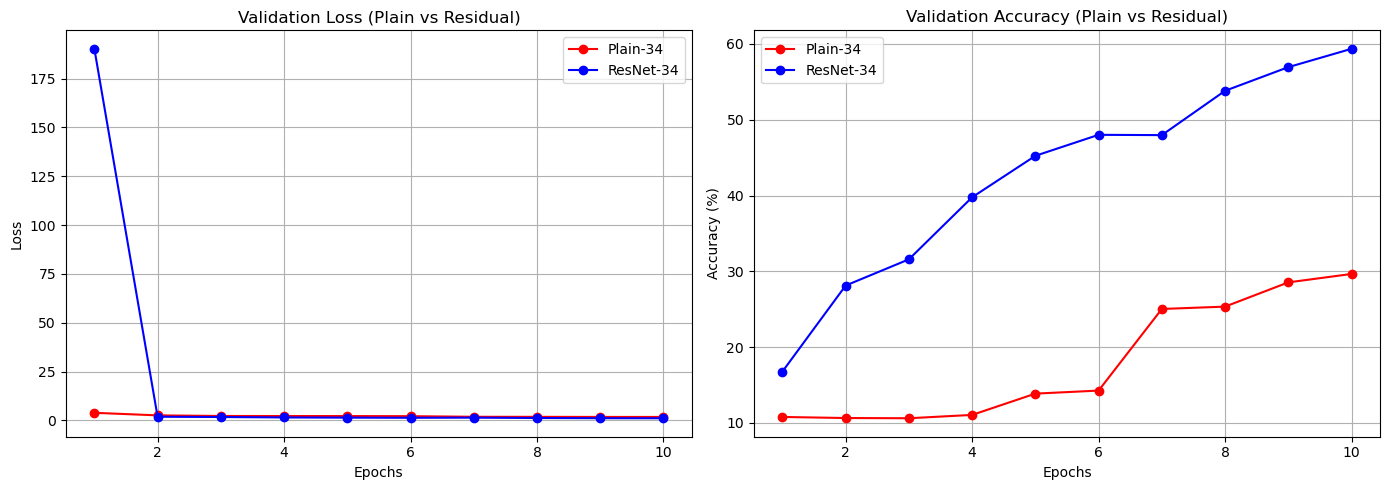

📌 Plain-34 최종 검증 정확도: 29.65%
📌 ResNet-34 최종 검증 정확도: 59.36%


In [52]:
# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10 # 시간 관계상 10~15 정도로 설정 (필요시 조절)

print("=== [1] Plain-34 모델 학습 시작 ===")
# ResNet 클래스에 PlainBasicBlock을 넣어 Plain-34 생성
plain_34 = ResNet(PlainBasicBlock, [3, 4, 6, 3], num_classes=10) 
plain_history = train_and_evaluate(plain_34, trainloader, testloader, EPOCHS, device)

print("\n=== [2] ResNet-34 모델 학습 시작 ===")
# 이전에 만든 build_resnet 함수 사용 (또는 ResNet(BasicBlock, ...))
resnet_34 = build_resnet(is_50=False, num_classes=10)
res_history = train_and_evaluate(resnet_34, trainloader, testloader, EPOCHS, device)

# --- 3. 검증 결과 시각화 (Ablation Study) ---
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))

# Validation Loss 비교 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, plain_history['val_loss'], 'r-o', label='Plain-34')
plt.plot(epochs_range, res_history['val_loss'], 'b-o', label='ResNet-34')
plt.title('Validation Loss (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Validation Accuracy 비교 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, plain_history['val_acc'], 'r-o', label='Plain-34')
plt.plot(epochs_range, res_history['val_acc'], 'b-o', label='ResNet-34')
plt.title('Validation Accuracy (Plain vs Residual)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 최종 정확도 출력 (마크다운 표에 넣을 값)
print(f"📌 Plain-34 최종 검증 정확도: {plain_history['val_acc'][-1]:.2f}%")
print(f"📌 ResNet-34 최종 검증 정확도: {res_history['val_acc'][-1]:.2f}%")

In [53]:
import torch
import torch.nn as nn

class PlainBottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        # 1x1 Conv
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        
        # 3x3 Conv
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        
        # 1x1 Conv
        self.conv3 = nn.Conv2d(planes, self.expansion*planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)
        
        self.relu = nn.ReLU(inplace=True)
        
        # ❌ shortcut 구성 요소 생략 (Plain 모델이므로)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        # ❌ out += self.shortcut(x) 제거 (핵심!)
        
        out = self.relu(out)
        
        return out

In [54]:
# 장치 설정 (이전에 정의했다면 생략 가능)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10 # 34-layers와 동일한 에폭 수로 설정

print("=== [3] Plain-50 모델 학습 시작 ===")
# ResNet 클래스에 PlainBottleneckBlock을 넣어 Plain-50 생성
plain_50 = ResNet(PlainBottleneckBlock, [3, 4, 6, 3], num_classes=10) 
plain_50_history = train_and_evaluate(plain_50, trainloader, testloader, EPOCHS, device)

print("\n=== [4] ResNet-50 모델 학습 시작 ===")
# 이전에 만든 build_resnet 함수 사용
resnet_50 = build_resnet(is_50=True, num_classes=10)
res_50_history = train_and_evaluate(resnet_50, trainloader, testloader, EPOCHS, device)

# 최종 정확도 출력 (마크다운 표에 넣을 값)
print(f"📌 Plain-50 최종 검증 정확도: {plain_50_history['val_acc'][-1]:.2f}%")
print(f"📌 ResNet-50 최종 검증 정확도: {res_50_history['val_acc'][-1]:.2f}%")

=== [3] Plain-50 모델 학습 시작 ===
Epoch [1/10] | Train Loss: 3.2616 | Val Loss: 2.3129 | Val Acc: 10.03%
Epoch [2/10] | Train Loss: 2.7387 | Val Loss: 3.0925 | Val Acc: 9.85%
Epoch [3/10] | Train Loss: 2.3240 | Val Loss: 2.4055 | Val Acc: 13.01%
Epoch [4/10] | Train Loss: 2.1614 | Val Loss: 2.0731 | Val Acc: 20.81%
Epoch [5/10] | Train Loss: 2.0673 | Val Loss: 2.0343 | Val Acc: 21.86%
Epoch [6/10] | Train Loss: 2.0117 | Val Loss: 2.0423 | Val Acc: 20.31%
Epoch [7/10] | Train Loss: 1.9869 | Val Loss: 2.0046 | Val Acc: 21.37%
Epoch [8/10] | Train Loss: 1.9614 | Val Loss: 2.0128 | Val Acc: 21.03%
Epoch [9/10] | Train Loss: 1.9391 | Val Loss: 2.0317 | Val Acc: 21.27%
Epoch [10/10] | Train Loss: 1.9317 | Val Loss: 1.9574 | Val Acc: 23.39%

=== [4] ResNet-50 모델 학습 시작 ===
Epoch [1/10] | Train Loss: 5.3251 | Val Loss: 4.8778 | Val Acc: 12.32%
Epoch [2/10] | Train Loss: 2.6608 | Val Loss: 2.2649 | Val Acc: 15.36%
Epoch [3/10] | Train Loss: 2.1585 | Val Loss: 1.9473 | Val Acc: 28.74%
Epoch [4/10] | 

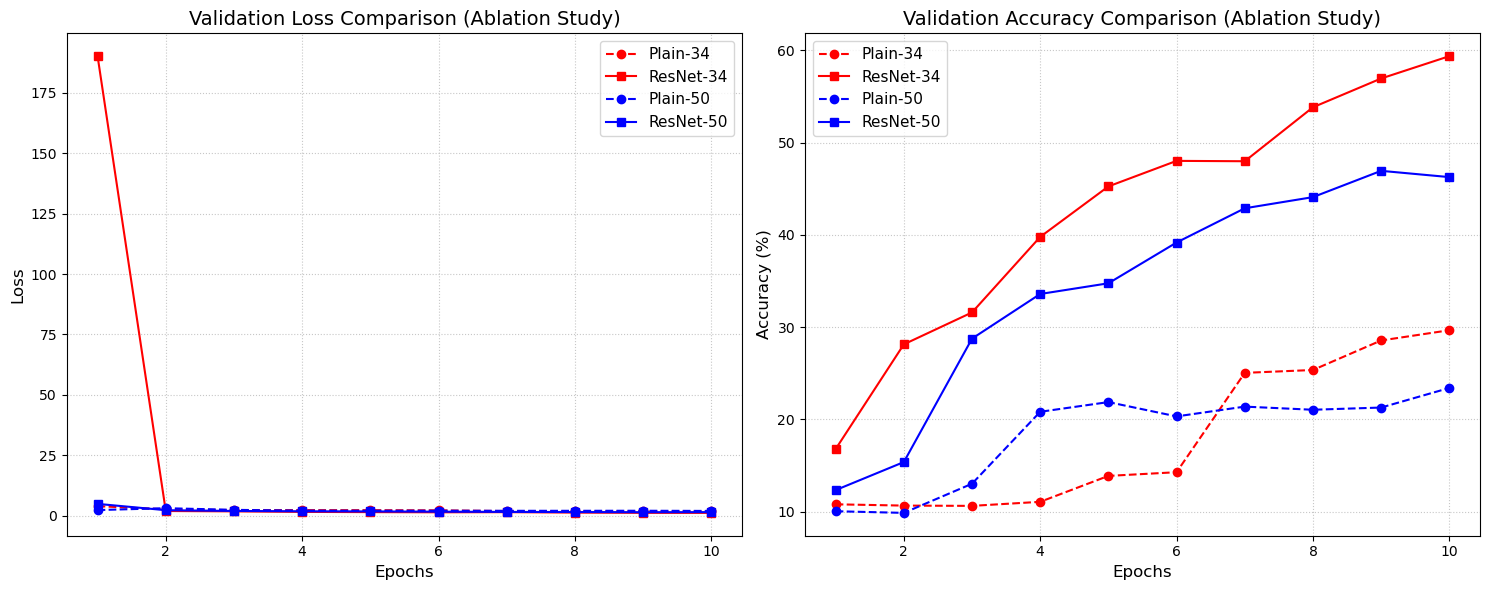

In [55]:
import matplotlib.pyplot as plt

# 에폭 범위 설정 (앞서 설정한 EPOCHS 변수 사용)
epochs_range = range(1, EPOCHS + 1)

# 그래프 전체 크기 설정
plt.figure(figsize=(15, 6))

# -----------------------------------------
# 1. Validation Loss 비교 그래프
# -----------------------------------------
plt.subplot(1, 2, 1)

# 34-layers (Red)
plt.plot(epochs_range, plain_history['val_loss'], color='red', linestyle='--', marker='o', label='Plain-34')
plt.plot(epochs_range, res_history['val_loss'], color='red', linestyle='-', marker='s', label='ResNet-34')

# 50-layers (Blue)
plt.plot(epochs_range, plain_50_history['val_loss'], color='blue', linestyle='--', marker='o', label='Plain-50')
plt.plot(epochs_range, res_50_history['val_loss'], color='blue', linestyle='-', marker='s', label='ResNet-50')

plt.title('Validation Loss Comparison (Ablation Study)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# -----------------------------------------
# 2. Validation Accuracy 비교 그래프
# -----------------------------------------
plt.subplot(1, 2, 2)

# 34-layers (Red)
plt.plot(epochs_range, plain_history['val_acc'], color='red', linestyle='--', marker='o', label='Plain-34')
plt.plot(epochs_range, res_history['val_acc'], color='red', linestyle='-', marker='s', label='ResNet-34')

# 50-layers (Blue)
plt.plot(epochs_range, plain_50_history['val_acc'], color='blue', linestyle='--', marker='o', label='Plain-50')
plt.plot(epochs_range, res_50_history['val_acc'], color='blue', linestyle='-', marker='s', label='ResNet-50')

plt.title('Validation Accuracy Comparison (Ablation Study)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()